# Analyzing Cosmic Variance in the 21-cm Signal

In this module, we examine the intrinsic statistical uncertainty, cosmic variance, of the 21-cm power spectrum. By keeping our ionization fraction ($Q_\text{HII}$) fixed and varying the initial density field seeds, we can quantify the sample variance in our $\Delta^2_{21}(k)$ bins.

First, we load the simulated realizations and compute standard descriptive statistics (mean, standard deviation, skewness, and kurtosis) to establish a theoretical noise floor for our inference pipeline.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Load the saved npz file
file_path = "cosmic_variance_results.npz"
data = np.load(file_path)

num_realizations = 1000 ## could be less than the total number of realizations in the file

# 2. Extract arrays
seeds = data['seeds']
zeta = data['zeta']
QHII_mean = data['QHII_mean']
P_all = data['P_all']
k_bins = data['k_bins']
kount = data['kount']
print(f"Loaded {len(seeds)} realizations.")

num_realizations = min(num_realizations, len(seeds))  # Ensure we don't exceed available realizations

seeds = seeds[:num_realizations]
zeta = zeta[:num_realizations]
QHII_mean = QHII_mean[:num_realizations]
P_all = P_all[:num_realizations, :]

# 3. Focus on the specific k-bin
k_val = k_bins[0]
P_k = P_all[:, 0]  # Extracts the power spectrum values for realizations

# 4. Compute statistics
mean_P = np.mean(P_k)
median_P = np.median(P_k)
std_P = np.std(P_k)
skew_P = stats.skew(P_k)
kurt_P = stats.kurtosis(P_k)  # excess kurtosis (Fisher)

print(f"Using {len(seeds)} realizations.")
print(f"k-bin center: {k_val:.3f} h/Mpc")
print(f"Mean P21:   {mean_P:.2f}")
print(f"Median P21: {median_P:.2f}")
print(f"Std Dev:    {std_P:.2f}")
print(f"Skewness:   {skew_P:.3f}")
print(f"Kurtosis:   {kurt_P:.3f}")
print(f"Poisson Std Dev: {mean_P / np.sqrt(kount[0, 0]):.2f}")

Loaded 100 realizations.
Using 100 realizations.
k-bin center: 0.553 h/Mpc
Mean P21:   11.16
Median P21: 11.17
Std Dev:    1.60
Skewness:   0.123
Kurtosis:   -0.102
Poisson Std Dev: 1.04


**Visualizing the Power Spectrum Distribution**

According to the Central Limit Theorem, the power spectrum estimator in a given $k$-bin should follow a roughly Gaussian distribution if the number of independent modes is sufficiently large. We evaluate this by comparing the empirical distribution of our realizations against two models:
1. A theoretical Gaussian derived purely from Poisson counting statistics.
2. A maximum-likelihood best-fit Gaussian.

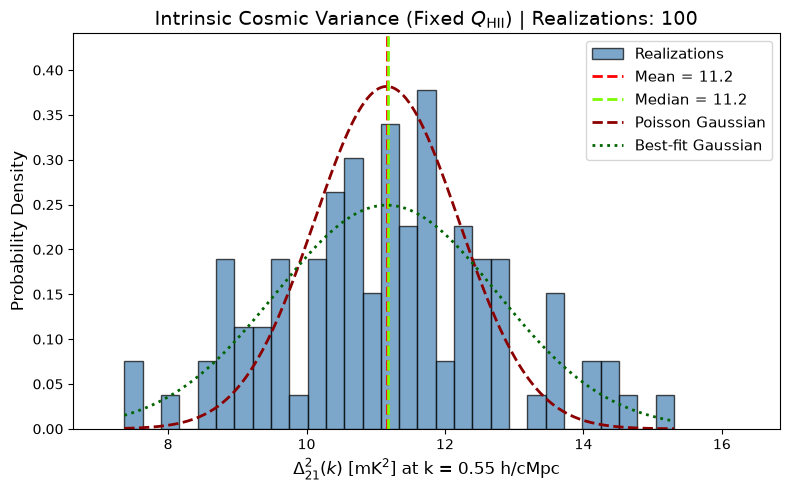

In [8]:
# Create the histogram as a normalized PDF
plt.figure(figsize=(8, 5))
counts, bin_edges, _ = plt.hist(P_k, bins=30, density=True, edgecolor='black', alpha=0.7, color='steelblue', label='Realizations')

# Add vertical markers for Mean and Median
plt.axvline(mean_P, color='red', linestyle='dashed', linewidth=2, 
            label=f'Mean = {mean_P:.1f}')
plt.axvline(median_P, color='lawngreen', linestyle='dashed', linewidth=2, 
            label=f'Median = {median_P:.1f}')

# Overplot a normalized Gaussian with mean = mean_P and std expected from Poisson errors
sigma_P = mean_P / np.sqrt(kount[0, 0])
x = np.linspace(P_k.min(), P_k.max(), 200)
gaussian_poisson = stats.norm.pdf(x, mean_P, sigma_P)
plt.plot(x, gaussian_poisson, color='darkred', linewidth=2, linestyle='--', label=f'Poisson Gaussian')

# Best-fit Gaussian to the histogram data using maximum-likelihood / curve-fit estimates
mu_fit, std_fit = stats.norm.fit(P_k)
gaussian_fit = stats.norm.pdf(x, mu_fit, std_fit)
plt.plot(x, gaussian_fit, color='darkgreen', linewidth=2, linestyle=':', label=f'Best-fit Gaussian')


# Formatting
xlabel_text = r"$\Delta^2_{21}(k)\ [\mathrm{mK}^2]$" + f" at k = {k_val:.2f} h/cMpc"
plt.xlabel(xlabel_text, fontsize=12)
plt.ylabel("Probability Density", fontsize=12)
plt.xlim(P_k.min() * 0.9, P_k.max() * 1.1)
plt.ylim(0, plt.gca().get_ylim()[1] * 1.1)

# Dynamic title logic
if np.allclose(QHII_mean, QHII_mean[0]):
    plt.title(f"Intrinsic Cosmic Variance (Fixed $Q_{{\\mathrm{{HII}}}}$) | Realizations: {num_realizations}", fontsize=14)
else:
    plt.title(f"Parameter Sampling Run | Realizations: {num_realizations}", fontsize=14)

plt.legend(fontsize=11)
plt.tight_layout()

plt.show()

**Key Takeaways**

We have now quantified the intrinsic cosmic variance of our 21-cm power spectrum. Even at a fixed $Q_{\text{HII}}$, different initial density seeds produce a distribution of power spectra. This irreducible scatter defines our fundamental noise floor.

**Next steps:**

Try changing the $k$-bin index in the code to look at a different spatial scale (different $k$). Does the power spectrum distribution become more or less Gaussian?